# LBG Classification - Final Model and Prediction Pipeline

This notebook: 
1. Trains the final model on 100% data
2. Saves the model and configuration
3. Provides prediction pipeline for full CLAUDS catalo

In [1]:
# Cell 1: Imports and Configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import lightgbm as lgb
import warnings
import os
import json
from datetime import datetime
from astropy.table import Table

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# --- Paths ---
DATA_PATH = "../data_processed/training_dataset_v2.csv"
MODEL_DIR = "../models"
PREDICTION_DIR = "../predictions"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PREDICTION_DIR, exist_ok=True)

# --- Best model configuration ---
BEST_MODEL_NAME = "core_err"
BEST_FEATURES = [
    'u_g', 'g_r', 'r_i', 'i_z', 'z_y',
    'mag_i',
    'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y'
]

# --- LightGBM parameters ---
LGBM_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

# --- Photometry configuration ---
PHOTOMETRY_COLUMNS = {
    'mag_u': 'uS',
    'mag_g': 'g',
    'mag_r': 'r',
    'mag_i': 'i',
    'mag_z': 'z',
    'mag_y': 'y',
    'err_u': 'uS_err',
    'err_g': 'g_err',
    'err_r': 'r_err',
    'err_i': 'i_err',
    'err_z': 'z_err',
    'err_y': 'y_err',
    'offset_mag': 'nihao',
}

# --- Selection criteria ---
CLASS_STAR_THRESHOLD = 1e99
SNR_THRESHOLD = 5.0
MAG_ERR_TO_SNR_FACTOR = 1.0857

# --- r-band magnitude cut (from paper) ---
MAG_R_MIN = 22.5
MAG_R_MAX = 23.75
APPLY_R_CUT = True  # Set to False to disable

print("Configuration loaded.")
print(f"Best model: {BEST_MODEL_NAME}")
print(f"Features: {BEST_FEATURES}")
print(f"r-band cut: {MAG_R_MIN} < r < {MAG_R_MAX} (enabled:  {APPLY_R_CUT})")

Configuration loaded.
Best model: core_err
Features: ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i', 'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y']
r-band cut: 22.5 < r < 23.75 (enabled:  True)


In [2]:
# Cell 2: Train Final Model on 100% Data

print("=" * 70)
print("TRAINING FINAL MODEL ON 100% DATA")
print("=" * 70)

# Load training data
df_train = pd. read_csv(DATA_PATH)
print(f"\nLoaded training data:  {len(df_train)} samples")

# =============================================================================
# Apply r-band magnitude cut
# =============================================================================
if APPLY_R_CUT and 'mag_r' in df_train.columns:
    print(f"\n[Applying r-band cut: {MAG_R_MIN} < r < {MAG_R_MAX}]")
    n_before = len(df_train)
    
    mag_r = df_train['mag_r']. values
    r_cut_mask = (mag_r > MAG_R_MIN) & (mag_r < MAG_R_MAX) & np.isfinite(mag_r)
    
    # Statistics by class before cut
    n_lbg_before = (df_train['is_lbg'] == 1).sum()
    n_non_lbg_before = (df_train['is_lbg'] == 0).sum()
    
    df_train = df_train[r_cut_mask].reset_index(drop=True)
    
    n_after = len(df_train)
    n_lbg_after = (df_train['is_lbg'] == 1).sum()
    n_non_lbg_after = (df_train['is_lbg'] == 0).sum()
    
    print(f"  Before:  {n_before: ,} (LBG: {n_lbg_before:,}, Non-LBG: {n_non_lbg_before:,})")
    print(f"  After:   {n_after:,} (LBG: {n_lbg_after:,}, Non-LBG: {n_non_lbg_after:,})")
    print(f"  Retained: {n_after/n_before*100:.1f}%")

print(f"\nTraining data:  {len(df_train)} samples")
print(f"  LBG: {(df_train['is_lbg']==1).sum()}")
print(f"  Non-LBG: {(df_train['is_lbg']==0).sum()}")

# Prepare features and labels
X = df_train[BEST_FEATURES].copy()
y = df_train['is_lbg'].copy()

# Check NaN
n_nan = X.isna().sum().sum()
print(f"\nTotal NaN in features: {n_nan}")
print("LightGBM will handle NaN natively.")

# Create dataset and train
print("\nTraining final model...")
train_data = lgb.Dataset(X, label=y)

# Train with fixed number of iterations
final_model = lgb.train(
    LGBM_PARAMS,
    train_data,
    num_boost_round=300
)

print(f"✓ Model trained with {final_model.num_trees()} trees")

TRAINING FINAL MODEL ON 100% DATA

Loaded training data:  2187 samples

[Applying r-band cut: 22.5 < r < 23.75]
  Before:   2,187 (LBG: 1,166, Non-LBG: 1,021)
  After:   2,187 (LBG: 1,166, Non-LBG: 1,021)
  Retained: 100.0%

Training data:  2187 samples
  LBG: 1166
  Non-LBG: 1021

Total NaN in features: 620
LightGBM will handle NaN natively.

Training final model...
✓ Model trained with 500 trees


In [3]:
# Cell 3: Evaluate Final Model (on training data for reference)

print("=" * 70)
print("FINAL MODEL EVALUATION (Training Data)")
print("=" * 70)

# Predict on training data
y_pred_proba = final_model.predict(X)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
print("\nTraining set metrics (for reference only):")
print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
print(f"  Precision: {precision_score(y, y_pred):.4f}")
print(f"  Recall:    {recall_score(y, y_pred):.4f}")
print(f"  F1:        {f1_score(y, y_pred):.4f}")
print(f"  AUC:       {roc_auc_score(y, y_pred_proba):.4f}")

# Feature importance
importance = pd.DataFrame({
    'feature': BEST_FEATURES,
    'importance': final_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance.to_string(index=False))

FINAL MODEL EVALUATION (Training Data)

Training set metrics (for reference only):
  Accuracy:  0.9488
  Precision: 0.9327
  Recall:    0.9743
  F1:        0.9530
  AUC:       0.9947

Feature Importance:
feature  importance
    r_i 4534.810036
    z_y 2968.878101
    u_g 2895.570768
    i_z 2876.907805
    g_r 2675.894045
  mag_i 2357.646257
  err_u 1601.163917
  err_y 1233.104905
  err_g  992.055295
  err_z  961.401089
  err_r  895.888655
  err_i  649.777793


In [4]:
# Cell 4: Save Model and Configuration

print("=" * 70)
print("SAVING MODEL AND CONFIGURATION")
print("=" * 70)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save model
model_path = os.path.join(MODEL_DIR, f"lbg_classifier_final_{timestamp}.txt")
final_model.save_model(model_path)
print(f"✓ Model saved:  {model_path}")

# 2. Save feature list
features_path = os. path.join(MODEL_DIR, f"features_{timestamp}.txt")
with open(features_path, 'w') as f:
    f.write('\n'. join(BEST_FEATURES))
print(f"✓ Features saved: {features_path}")

# 3. Save full configuration as JSON
config = {
    'model_name': BEST_MODEL_NAME,
    'model_file': os.path.basename(model_path),
    'features': BEST_FEATURES,
    'lgbm_params': LGBM_PARAMS,
    'photometry_columns': PHOTOMETRY_COLUMNS,
    'class_star_threshold': CLASS_STAR_THRESHOLD,
    'snr_threshold': SNR_THRESHOLD,
    'training_samples': len(df_train),
    'training_date': timestamp,
    'training_metrics': {
        'auc': float(roc_auc_score(y, y_pred_proba)),
        'f1': float(f1_score(y, y_pred)),
    }
}

config_path = os.path.join(MODEL_DIR, f"config_{timestamp}.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Configuration saved: {config_path}")

# 4. Save feature importance
importance_path = os. path.join(MODEL_DIR, f"feature_importance_{timestamp}.csv")
importance.to_csv(importance_path, index=False)
print(f"✓ Feature importance saved: {importance_path}")


SAVING MODEL AND CONFIGURATION
✓ Model saved:  ../models/lbg_classifier_final_20260102_061313.txt
✓ Features saved: ../models/features_20260102_061313.txt
✓ Configuration saved: ../models/config_20260102_061313.json
✓ Feature importance saved: ../models/feature_importance_20260102_061313.csv


In [5]:
# Cell 5: Define Prediction Pipeline Functions

def compute_snr(mag_err:  np.ndarray) -> np.ndarray:
    """Compute SNR from magnitude error."""
    valid = (mag_err > 0) & (mag_err < 99) & np.isfinite(mag_err)
    snr = np.full_like(mag_err, np. nan, dtype=float)
    snr[valid] = MAG_ERR_TO_SNR_FACTOR / mag_err[valid]
    return snr


def is_valid_detection(mag:  np.ndarray, mag_err: np.ndarray) -> np.ndarray:
    """Check if measurement is valid detection (SNR >= threshold)."""
    snr = compute_snr(mag_err)
    is_valid_snr = snr >= SNR_THRESHOLD
    is_valid_mag = np.isfinite(mag) & (mag > 0) & (mag < 50)
    return is_valid_snr & is_valid_mag


def process_magnitude(mag: np.ndarray, mag_err: np.ndarray) -> np.ndarray:
    """Process magnitude:  keep valid detections, NaN for non-detections."""
    is_detected = is_valid_detection(mag, mag_err)
    return np.where(is_detected, mag, np.nan)


def apply_selection_criteria(table: Table, field: str, 
                              apply_r_cut: bool = True,
                              mag_r_min: float = 22.5,
                              mag_r_max: float = 23.75) -> np.ndarray:
    """
    Apply quality selection criteria. 
    
    Criteria:
    1.  MASK == 0
    2. FLAG_FIELD_BINARY[:,0] == True
    3. FLAG_FIELD_BINARY[:,1] (COSMOS) or [:,2] (XMM) == True
    4. CLASS_STAR < 0.8 (remove stars)
    5. 22.5 < mag_r < 23.75 (if apply_r_cut is True)
    """
    n_total = len(table)
    
    # Field selection
    mask = np.array(table['MASK'])
    flag_field = np.array(table['FLAG_FIELD_BINARY'])
    
    cond_mask = (mask == 0)
    cond_flag0 = flag_field[:, 0]. astype(bool)
    
    if field. upper() == 'COSMOS':
        cond_field = flag_field[:, 1].astype(bool)
    else: 
        cond_field = flag_field[:, 2].astype(bool)
    
    field_selection = cond_mask # & cond_flag0 & cond_field
    
    # Star removal
    class_star = np.array(table['CLASS_STAR_HSC_I'], dtype=float)
    is_valid_cs = np.isfinite(class_star) & (class_star >= 0) & (class_star <= 1)
    is_galaxy = (is_valid_cs & (class_star < CLASS_STAR_THRESHOLD)) | (~is_valid_cs)
    
    # Combine field + star selection
    selection = field_selection & is_galaxy
    
    print(f"  Selection summary:")
    print(f"    Total sources: {n_total:,}")
    print(f"    Pass field selection: {np.sum(field_selection):,} ({np.sum(field_selection)/n_total*100:.1f}%)")
    print(f"    Pass star removal: {np.sum(selection):,}")
    
    # r-band magnitude cut
    if apply_r_cut: 
        # Get mag_r with offset correction
        mag_r_col = PHOTOMETRY_COLUMNS. get('mag_r', 'r')
        offset_col = PHOTOMETRY_COLUMNS. get('offset_mag', 'nihao')
        
        if mag_r_col in table.colnames: 
            mag_r_raw = np.asarray(table[mag_r_col], dtype=np.float64)
            
            if offset_col in table.colnames:
                offset = np.asarray(table[offset_col], dtype=np.float64)
                mag_r = mag_r_raw + offset
            else:
                mag_r = mag_r_raw
            
            r_cut = (mag_r > mag_r_min) & (mag_r < mag_r_max) & np.isfinite(mag_r)
            
            n_before_r_cut = np.sum(selection)
            selection = selection & r_cut
            n_after_r_cut = np.sum(selection)
            
            print(f"    Pass r-band cut ({mag_r_min} < r < {mag_r_max}): {n_after_r_cut:,} ({n_after_r_cut/n_before_r_cut*100:.1f}% of previous)")
        else:
            print(f"    WARNING: {mag_r_col} not found, skipping r-band cut")
    
    print(f"    Final selection: {np.sum(selection):,} ({np.sum(selection)/n_total*100:.2f}%)")
    
    return selection


def extract_features(table: Table) -> pd.DataFrame:
    """
    Extract features from CLAUDS photometric catalog.
    Same processing as training data.
    """
    n_sources = len(table)
    
    # Get offset magnitude
    if 'nihao' in table.colnames:
        offset_mag = np.array(table['OFFSET_MAG_2s'])
    else:
        offset_mag = np.zeros(n_sources)
    
    # Extract and process magnitudes
    data = {}
    bands = ['u', 'g', 'r', 'i', 'z', 'y']
    
    for band in bands:
        mag_col = PHOTOMETRY_COLUMNS.get(f'mag_{band}')
        err_col = PHOTOMETRY_COLUMNS.get(f'err_{band}')
        
        if mag_col in table.colnames and err_col in table.colnames:
            mag_raw = np.array(table[mag_col])
            mag_err = np.array(table[err_col])
            
            # Apply offset correction
            mag_corrected = mag_raw + offset_mag
            
            # Process (NaN for non-detections)
            mag_processed = process_magnitude(mag_corrected, mag_err)
            
            data[f'mag_{band}'] = mag_processed
            data[f'err_{band}'] = mag_err
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Compute colors
    df['u_g'] = df['mag_u'] - df['mag_g']
    df['g_r'] = df['mag_g'] - df['mag_r']
    df['r_i'] = df['mag_r'] - df['mag_i']
    df['i_z'] = df['mag_i'] - df['mag_z']
    df['z_y'] = df['mag_z'] - df['mag_y']
    
    return df


def predict_lbg(
    model,
    features_df: pd.DataFrame,
    feature_list: list,
    threshold: float = 0.9
) -> tuple: 
    """
    Predict LBG probability and class.
    """
    X = features_df[feature_list].copy()
    prob = model.predict(X)
    pred = (prob >= threshold).astype(int)
    return prob, pred


print("Prediction pipeline functions defined.")


def run_prediction_pipeline(
    path_raw: str,
    field_name: str,
    model,
    feature_list: list,
    output_path: str = None,
    threshold: float = 0.5,
    apply_r_cut:  bool = True,
    mag_r_min: float = 22.5,
    mag_r_max: float = 23.75
) -> pd.DataFrame:
    """
    Run complete prediction pipeline on CLAUDS catalog.
    
    Parameters
    ----------
    path_raw :  str
        Path to CLAUDS photometric catalog
    field_name :  str
        Field name ('COSMOS' or 'XMM-LSS')
    model : lgb.Booster
        Trained LightGBM model
    feature_list : list
        List of feature names
    output_path : str, optional
        Path to save predictions
    threshold : float
        Classification threshold (default 0.5)
    apply_r_cut : bool
        If True, apply r-band magnitude cut
    mag_r_min, mag_r_max : float
        r-band magnitude range
        
    Returns
    -------
    df_results : pd.DataFrame
        Prediction results
    """
    print("=" * 70)
    print(f"PREDICTION PIPELINE: {field_name}")
    print("=" * 70)
    
    if apply_r_cut:
        print(f"[r-band cut enabled: {mag_r_min} < r < {mag_r_max}]")
    
    # Step 1: Load data
    print("\n[1] Loading data...")
    table = Table. read(path_raw, hdu=1)
    n_total = len(table)
    print(f"    Loaded {n_total:,} sources")
    
    # Step 2: Apply selection criteria (including r-band cut)
    print("\n[2] Applying selection criteria...")
    selection_mask = apply_selection_criteria(
        table, field_name, 
        apply_r_cut=apply_r_cut,
        mag_r_min=mag_r_min,
        mag_r_max=mag_r_max
    )
    
    # Step 3: Extract features for selected sources
    print("\n[3] Extracting features...")
    table_selected = table[selection_mask]
    features_df = extract_features(table_selected)
    print(f"    Extracted features for {len(features_df):,} sources")
    
    # Step 4: Predict
    print("\n[4] Running predictions...")
    prob, pred = predict_lbg(model, features_df, feature_list, threshold)
    
    n_lbg = np.sum(pred == 1)
    n_non_lbg = np.sum(pred == 0)
    print(f"    Predicted LBG: {n_lbg:,} ({n_lbg/len(pred)*100:.1f}%)")
    print(f"    Predicted Non-LBG: {n_non_lbg:,} ({n_non_lbg/len(pred)*100:.1f}%)")
    
    # Step 5: Create results DataFrame
    print("\n[5] Creating results DataFrame...")
    df_results = pd.DataFrame({
        'ID': np.array(table_selected['ID']),
        'RA': np.array(table_selected['RA']),
        'DEC': np.array(table_selected['DEC']),
        'field': field_name,
        'lbg_prob': prob,
        'lbg_pred':  pred,
    })
    
    # Add key features for reference
    for col in ['mag_r', 'mag_i', 'u_g', 'g_r', 'r_i']: 
        if col in features_df.columns:
            df_results[col] = features_df[col]. values
    
    # Add photo-z if available
    if 'ZPHOT' in table_selected.colnames:
        df_results['photo_z'] = np.array(table_selected['ZPHOT'])
    
    # Step 6: Save results
    if output_path:
        df_results.to_csv(output_path, index=False)
        print(f"\n✓ Results saved:  {output_path}")
    
    # Summary statistics
    print("\n" + "-" * 40)
    print("SUMMARY")
    print("-" * 40)
    print(f"  Total sources processed: {len(df_results):,}")
    print(f"  Predicted LBG (prob >= {threshold}): {n_lbg:,}")
    print(f"  LBG probability distribution:")
    print(f"    Mean: {prob.mean():.3f}")
    print(f"    Median: {np.median(prob):.3f}")
    print(f"    Std: {prob.std():.3f}")
    
    return df_results


print("Full prediction pipeline defined.")

Prediction pipeline functions defined.
Full prediction pipeline defined.


In [16]:
# Cell 7: Run Prediction on COSMOS

df_cosmos = run_prediction_pipeline(
    path_raw="../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits",
    field_name="COSMOS",
    model=final_model,
    feature_list=BEST_FEATURES,
    output_path=os.path.join(PREDICTION_DIR, f"predictions_COSMOS_{timestamp}.csv"),
    threshold=0.95,
    apply_r_cut=APPLY_R_CUT,
    mag_r_min=MAG_R_MIN,
    mag_r_max=MAG_R_MAX
)

PREDICTION PIPELINE: COSMOS
[r-band cut enabled: 22.5 < r < 23.75]

[1] Loading data...
    Loaded 5,263,013 sources

[2] Applying selection criteria...
  Selection summary:
    Total sources: 5,263,013
    Pass field selection: 4,426,066 (84.1%)
    Pass star removal: 4,426,066
    Pass r-band cut (22.5 < r < 23.75): 251,282 (5.7% of previous)
    Final selection: 251,282 (4.77%)

[3] Extracting features...
    Extracted features for 251,282 sources

[4] Running predictions...
    Predicted LBG: 2,462 (1.0%)
    Predicted Non-LBG: 248,820 (99.0%)

[5] Creating results DataFrame...

✓ Results saved:  ../predictions/predictions_COSMOS_20260102_061313.csv

----------------------------------------
SUMMARY
----------------------------------------
  Total sources processed: 251,282
  Predicted LBG (prob >= 0.95): 2,462
  LBG probability distribution:
    Mean: 0.209
    Median: 0.074
    Std: 0.267


In [17]:
# Cell 8: Run Prediction on XMM-LSS

df_xmm = run_prediction_pipeline(
    path_raw="../data_Clauds/XMMLSS_6bands-SExtractor-Lephare.fits",
    field_name="XMM-LSS",
    model=final_model,
    feature_list=BEST_FEATURES,
    output_path=os.path.join(PREDICTION_DIR, f"predictions_XMM_{timestamp}.csv"),
    threshold=0.95,
    apply_r_cut=APPLY_R_CUT,
    mag_r_min=MAG_R_MIN,
    mag_r_max=MAG_R_MAX
)

PREDICTION PIPELINE: XMM-LSS
[r-band cut enabled: 22.5 < r < 23.75]

[1] Loading data...
    Loaded 5,166,244 sources

[2] Applying selection criteria...
  Selection summary:
    Total sources: 5,166,244
    Pass field selection: 4,491,672 (86.9%)
    Pass star removal: 4,491,672
    Pass r-band cut (22.5 < r < 23.75): 215,853 (4.8% of previous)
    Final selection: 215,853 (4.18%)

[3] Extracting features...
    Extracted features for 215,853 sources

[4] Running predictions...
    Predicted LBG: 5,458 (2.5%)
    Predicted Non-LBG: 210,395 (97.5%)

[5] Creating results DataFrame...

✓ Results saved:  ../predictions/predictions_XMM_20260102_061313.csv

----------------------------------------
SUMMARY
----------------------------------------
  Total sources processed: 215,853
  Predicted LBG (prob >= 0.95): 5,458
  LBG probability distribution:
    Mean: 0.289
    Median: 0.151
    Std: 0.303


In [18]:
# Cell 9: Combine and Analyze Results

print("=" * 70)
print("COMBINED RESULTS ANALYSIS")
print("=" * 70)

# Combine results
df_all = pd.concat([df_cosmos, df_xmm], ignore_index=True)
print(f"\nTotal sources: {len(df_all):,}")

# Overall statistics
n_lbg_total = (df_all['lbg_pred'] == 1).sum()
print(f"Total predicted LBG: {n_lbg_total:,} ({n_lbg_total/len(df_all)*100:.1f}%)")

# By field
print("\nBy Field:")
for field in df_all['field']. unique():
    mask = df_all['field'] == field
    n_field = mask.sum()
    n_lbg = (df_all. loc[mask, 'lbg_pred'] == 1).sum()
    print(f"  {field}: {n_lbg:,} LBG out of {n_field:,} ({n_lbg/n_field*100:.1f}%)")

# Save combined results
combined_path = os.path.join(PREDICTION_DIR, f"predictions_all_{timestamp}.csv")
df_all.to_csv(combined_path, index=False)
print(f"\n✓ Combined results saved: {combined_path}")

COMBINED RESULTS ANALYSIS

Total sources: 467,135
Total predicted LBG: 7,920 (1.7%)

By Field:
  COSMOS: 2,462 LBG out of 251,282 (1.0%)
  XMM-LSS: 5,458 LBG out of 215,853 (2.5%)

✓ Combined results saved: ../predictions/predictions_all_20260102_061313.csv


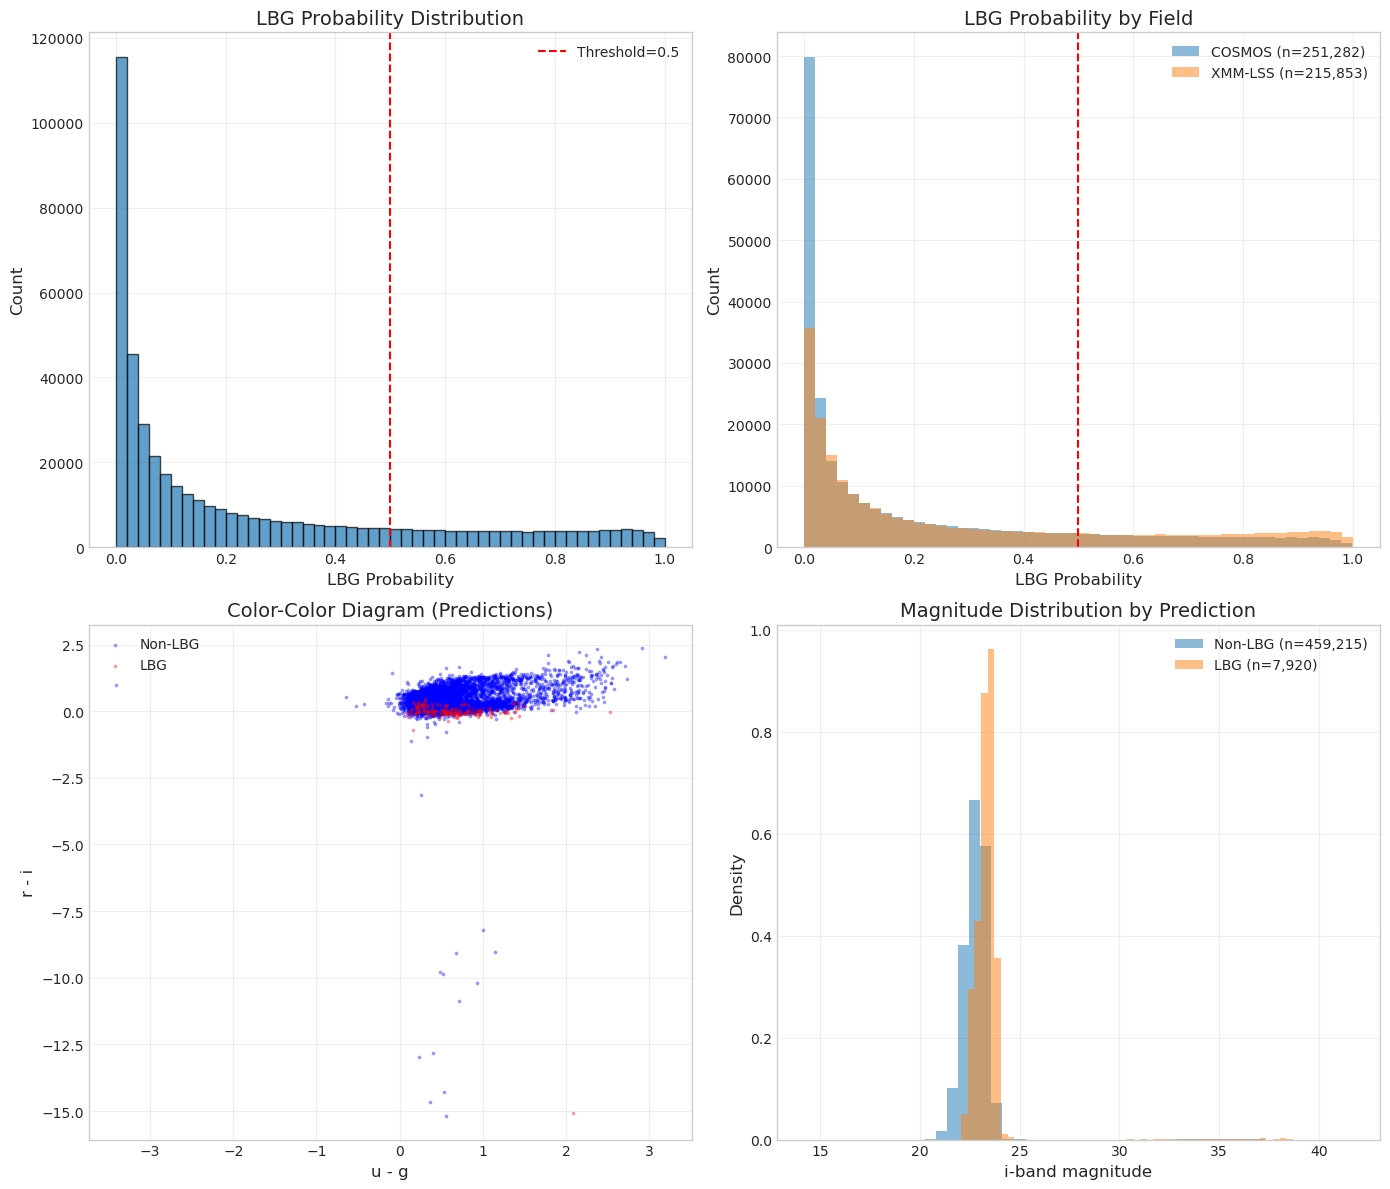

In [19]:
# Cell 10: Visualization - Prediction Distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Probability histogram
ax1 = axes[0, 0]
ax1.hist(df_all['lbg_prob'], bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(0.5, color='red', linestyle='--', label='Threshold=0.5')
ax1.set_xlabel('LBG Probability', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('LBG Probability Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Probability by field
ax2 = axes[0, 1]
for field in df_all['field']. unique():
    data = df_all[df_all['field'] == field]['lbg_prob']
    ax2.hist(data, bins=50, alpha=0.5, label=f'{field} (n={len(data):,})')
ax2.axvline(0.5, color='red', linestyle='--')
ax2.set_xlabel('LBG Probability', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('LBG Probability by Field', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Color-color diagram with predictions
ax3 = axes[1, 0]
lbg_mask = df_all['lbg_pred'] == 1
non_lbg_mask = df_all['lbg_pred'] == 0

# Sample for visualization
sample_size = min(10000, len(df_all))
sample_idx = np.random.choice(len(df_all), sample_size, replace=False)
df_sample = df_all.iloc[sample_idx]

ax3.scatter(df_sample[df_sample['lbg_pred']==0]['u_g'], 
            df_sample[df_sample['lbg_pred']==0]['r_i'],
            alpha=0.3, s=3, label='Non-LBG', c='blue')
ax3.scatter(df_sample[df_sample['lbg_pred']==1]['u_g'], 
            df_sample[df_sample['lbg_pred']==1]['r_i'],
            alpha=0.3, s=3, label='LBG', c='red')
ax3.set_xlabel('u - g', fontsize=12)
ax3.set_ylabel('r - i', fontsize=12)
ax3.set_title('Color-Color Diagram (Predictions)', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Magnitude distribution
ax4 = axes[1, 1]
ax4.hist(df_all[non_lbg_mask]['mag_i']. dropna(), bins=50, alpha=0.5, 
         label=f'Non-LBG (n={non_lbg_mask.sum():,})', density=True)
ax4.hist(df_all[lbg_mask]['mag_i'].dropna(), bins=50, alpha=0.5, 
         label=f'LBG (n={lbg_mask.sum():,})', density=True)
ax4.set_xlabel('i-band magnitude', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Magnitude Distribution by Prediction', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(os.path.join(PREDICTION_DIR, f'prediction_analysis_{timestamp}.png'), 
            # dpi=150, bbox_inches='tight')
plt.show()

# print(f"\n✓ Figure saved: {PREDICTION_DIR}/prediction_analysis_{timestamp}.png")

In [20]:
# Cell 11: High-Confidence LBG Candidates

print("=" * 70)
print("HIGH-CONFIDENCE LBG CANDIDATES")
print("=" * 70)

# Different probability thresholds
thresholds = [0.5, 0.7, 0.8, 0.9]

print("\nLBG candidates at different thresholds:")
print("-" * 50)
print(f"{'Threshold':<12} {'N_LBG':<12} {'Percentage':<12}")
print("-" * 50)

for thresh in thresholds:
    n_lbg = (df_all['lbg_prob'] >= thresh).sum()
    pct = n_lbg / len(df_all) * 100
    print(f"{thresh:<12.1f} {n_lbg:<12,} {pct:<12.2f}%")

# Save high-confidence candidates (prob >= 0.8)
high_conf_mask = df_all['lbg_prob'] >= 0.8
df_high_conf = df_all[high_conf_mask]. copy()
df_high_conf = df_high_conf.sort_values('lbg_prob', ascending=False)

high_conf_path = os.path.join(PREDICTION_DIR, f"lbg_candidates_high_conf_{timestamp}.csv")
df_high_conf.to_csv(high_conf_path, index=False)

print(f"\n✓ High-confidence candidates (prob >= 0.8) saved: {high_conf_path}")
print(f"  Total:  {len(df_high_conf):,} candidates")

# Preview
print("\nTop 10 highest probability candidates:")
print(df_high_conf[['ID', 'RA', 'DEC', 'field', 'lbg_prob', 'mag_i', 'u_g', 'r_i']].head(10).to_string())

HIGH-CONFIDENCE LBG CANDIDATES

LBG candidates at different thresholds:
--------------------------------------------------
Threshold    N_LBG        Percentage  
--------------------------------------------------
0.5          95,701       20.49       %
0.7          55,948       11.98       %
0.8          37,487       8.02        %
0.9          18,175       3.89        %

✓ High-confidence candidates (prob >= 0.8) saved: ../predictions/lbg_candidates_high_conf_20260102_061313.csv
  Total:  37,487 candidates

Top 10 highest probability candidates:
             ID         RA       DEC    field  lbg_prob   mag_i    u_g    r_i
375960  3012026  36.938288 -4.795728  XMM-LSS  0.999741  23.481  1.596 -0.117
421337  4472615  35.803591 -3.798149  XMM-LSS  0.999580  23.386  1.683 -0.107
423244  4498875  35.979511 -3.468079  XMM-LSS  0.999496  23.339  1.936 -0.116
410866  4210564  36.304778 -3.656106  XMM-LSS  0.999487  23.217  1.933 -0.109
459054  5001269  37.028986 -3.923626  XMM-LSS  0.999208  2

In [21]:
# Cell 12: Final Summary

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"""
MODEL INFORMATION
  Model: LightGBM ({BEST_MODEL_NAME})
  Features: {len(BEST_FEATURES)} features
  Training samples: {len(df_train):,}
  Training AUC:n {roc_auc_score(y, y_pred_proba):.4f}
  
SELECTION CRITERIA
  CLASS_STAR < {CLASS_STAR_THRESHOLD}
  r-band cut: {MAG_R_MIN} < r < {MAG_R_MAX} (enabled:  {APPLY_R_CUT})

PREDICTION RESULTS
  Total sources processed: {len(df_all):,}
    - COSMOS: {len(df_cosmos):,}
    - XMM-LSS: {len(df_xmm):,}
  
  Predicted LBG (prob >= 0.5): {(df_all['lbg_prob'] >= 0.5).sum():,}
  Predicted LBG (prob >= 0.7): {(df_all['lbg_prob'] >= 0.7).sum():,}
  Predicted LBG (prob >= 0.8): {(df_all['lbg_prob'] >= 0.8).sum():,}
  Predicted LBG (prob >= 0.9): {(df_all['lbg_prob'] >= 0.9).sum():,}

SAVED FILES
  Model: {model_path}
  Config: {config_path}
  Features: {features_path}
  Feature Importance: {importance_path}
  
  Predictions (COSMOS): {PREDICTION_DIR}/predictions_COSMOS_{timestamp}.csv
  Predictions (XMM): {PREDICTION_DIR}/predictions_XMM_{timestamp}.csv
  Predictions (All): {combined_path}
  High-confidence: {high_conf_path}
""")

print("=" * 70)
print("✓ PIPELINE COMPLETE")
print("=" * 70)

FINAL SUMMARY

MODEL INFORMATION
  Model: LightGBM (core_err)
  Features: 12 features
  Training samples: 2,187
  Training AUC:n 0.9947
  
SELECTION CRITERIA
  CLASS_STAR < 1e+99
  r-band cut: 22.5 < r < 23.75 (enabled:  True)

PREDICTION RESULTS
  Total sources processed: 467,135
    - COSMOS: 251,282
    - XMM-LSS: 215,853
  
  Predicted LBG (prob >= 0.5): 95,701
  Predicted LBG (prob >= 0.7): 55,948
  Predicted LBG (prob >= 0.8): 37,487
  Predicted LBG (prob >= 0.9): 18,175

SAVED FILES
  Model: ../models/lbg_classifier_final_20260102_061313.txt
  Config: ../models/config_20260102_061313.json
  Features: ../models/features_20260102_061313.txt
  Feature Importance: ../models/feature_importance_20260102_061313.csv
  
  Predictions (COSMOS): ../predictions/predictions_COSMOS_20260102_061313.csv
  Predictions (XMM): ../predictions/predictions_XMM_20260102_061313.csv
  Predictions (All): ../predictions/predictions_all_20260102_061313.csv
  High-confidence: ../predictions/lbg_candidates_h

In [22]:
# Cell 13: Color-Color Box Selection Definition
# Reproduce Figure 5 from the reference paper: 
# Color-color box selection criteria (COSMOS TMG u-dropout):
# - (i) u - g > 0.3
# - (ii) -0.5 < g - r < 1
# - (iv) [u - g > 2.2 × (g - r) + 0.32] ∪ [u - g > 0.9 ∩ u - g > 1.6 × (g - r) + 0.75]

def apply_color_box_selection(df):
    """
    Apply color-color box selection criteria for LBG selection.
    
    Criteria from the paper (COSMOS TMG u-dropout):
    (i)   u - g > 0.3
    (ii)  -0.5 < g - r < 1
    (iv)  [u - g > 2.2 × (g - r) + 0.32] OR [u - g > 0.9 AND u - g > 1.6 × (g - r) + 0.75]
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'u_g' and 'g_r' columns
        
    Returns
    -------
    selection :  np.ndarray
        Boolean mask for selected sources
    """
    # Convert to native byte order if needed
    u_g = np.asarray(df['u_g'].values, dtype=np.float64)
    g_r = np.asarray(df['g_r'].values, dtype=np.float64)
    
    # Handle NaN
    valid = np.isfinite(u_g) & np.isfinite(g_r)
    
    # Condition (i): u - g > 0.3
    cond_i = u_g > 0.3
    
    # Condition (ii): -0.5 < g - r < 1
    cond_ii = (g_r > -0.5) & (g_r < 1.0)
    
    # Condition (iv): complex diagonal cut
    # Part a: u - g > 2.2 × (g - r) + 0.32
    cond_iv_a = u_g > 2.2 * g_r + 0.32
    # Part b: u - g > 0.9 AND u - g > 1.6 × (g - r) + 0.75
    cond_iv_b = (u_g > 0.9) & (u_g > 1.6 * g_r + 0.75)
    # Combined: a OR b
    cond_iv = cond_iv_a | cond_iv_b
    
    # Final selection:  all conditions AND valid data
    selection = valid & cond_i & cond_ii & cond_iv
    
    return selection


def get_box_selection_boundary(g_r_range):
    """
    Calculate the lower boundary of the color-box selection region.
    
    Parameters
    ----------
    g_r_range : np.ndarray
        Array of g-r values
        
    Returns
    -------
    lower_bound : np.ndarray
        Lower boundary of u-g for each g-r value
    """
    lower_bound = np.zeros_like(g_r_range)
    for i, gr in enumerate(g_r_range):
        # Condition (i): u_g > 0.3
        bound1 = 0.3
        # Condition (iv) part a: u_g > 2.2 * g_r + 0.32
        bound2 = 2.2 * gr + 0.32
        # Condition (iv) part b: u_g > max(0.9, 1.6 * g_r + 0.75)
        bound3 = max(0.9, 1.6 * gr + 0.75)
        # The selection boundary is the minimum of (bound2, bound3) but at least bound1
        lower_bound[i] = max(bound1, min(bound2, bound3))
    return lower_bound


def ensure_native_byteorder(arr):
    """
    Ensure array is in native byte order. 
    Fixes 'Big-endian buffer not supported on little-endian compiler' error.
    """
    if arr.dtype.byteorder == '>':
        return arr. astype(arr.dtype.newbyteorder('='))
    return arr


print("Color-box selection functions defined.")

Color-box selection functions defined.


In [23]:
# Cell 14: Apply Color-Box Selection to Predictions

print("=" * 70)
print("APPLYING COLOR-BOX SELECTION TO FULL CLAUDS DATA")
print("=" * 70)

# Apply color-box selection to each field
df_cosmos['box_sel'] = apply_color_box_selection(df_cosmos)
df_xmm['box_sel'] = apply_color_box_selection(df_xmm)
df_all['box_sel'] = apply_color_box_selection(df_all)

# Summary
print("\n[1] Color-Box Selection Results:")
for name, df_field in [('COSMOS', df_cosmos), ('XMM-LSS', df_xmm), ('BOTH', df_all)]:
    n_total = len(df_field)
    n_box = df_field['box_sel'].sum()
    n_ml = (df_field['lbg_pred'] == 1).sum()
    n_both = (df_field['box_sel'] & (df_field['lbg_pred'] == 1)).sum()
    
    print(f"\n  {name}:")
    print(f"    Total sources: {n_total: ,}")
    print(f"    Color-box selection: {n_box:,} ({n_box/n_total*100:.2f}%)")
    print(f"    ML selection: {n_ml:,} ({n_ml/n_total*100:.2f}%)")
    print(f"    Both methods: {n_both:,}")

APPLYING COLOR-BOX SELECTION TO FULL CLAUDS DATA

[1] Color-Box Selection Results:

  COSMOS:
    Total sources:  251,282
    Color-box selection: 1,382 (0.55%)
    ML selection: 2,462 (0.98%)
    Both methods: 160

  XMM-LSS:
    Total sources:  215,853
    Color-box selection: 2,626 (1.22%)
    ML selection: 5,458 (2.53%)
    Both methods: 354

  BOTH:
    Total sources:  467,135
    Color-box selection: 4,008 (0.86%)
    ML selection: 7,920 (1.70%)
    Both methods: 514


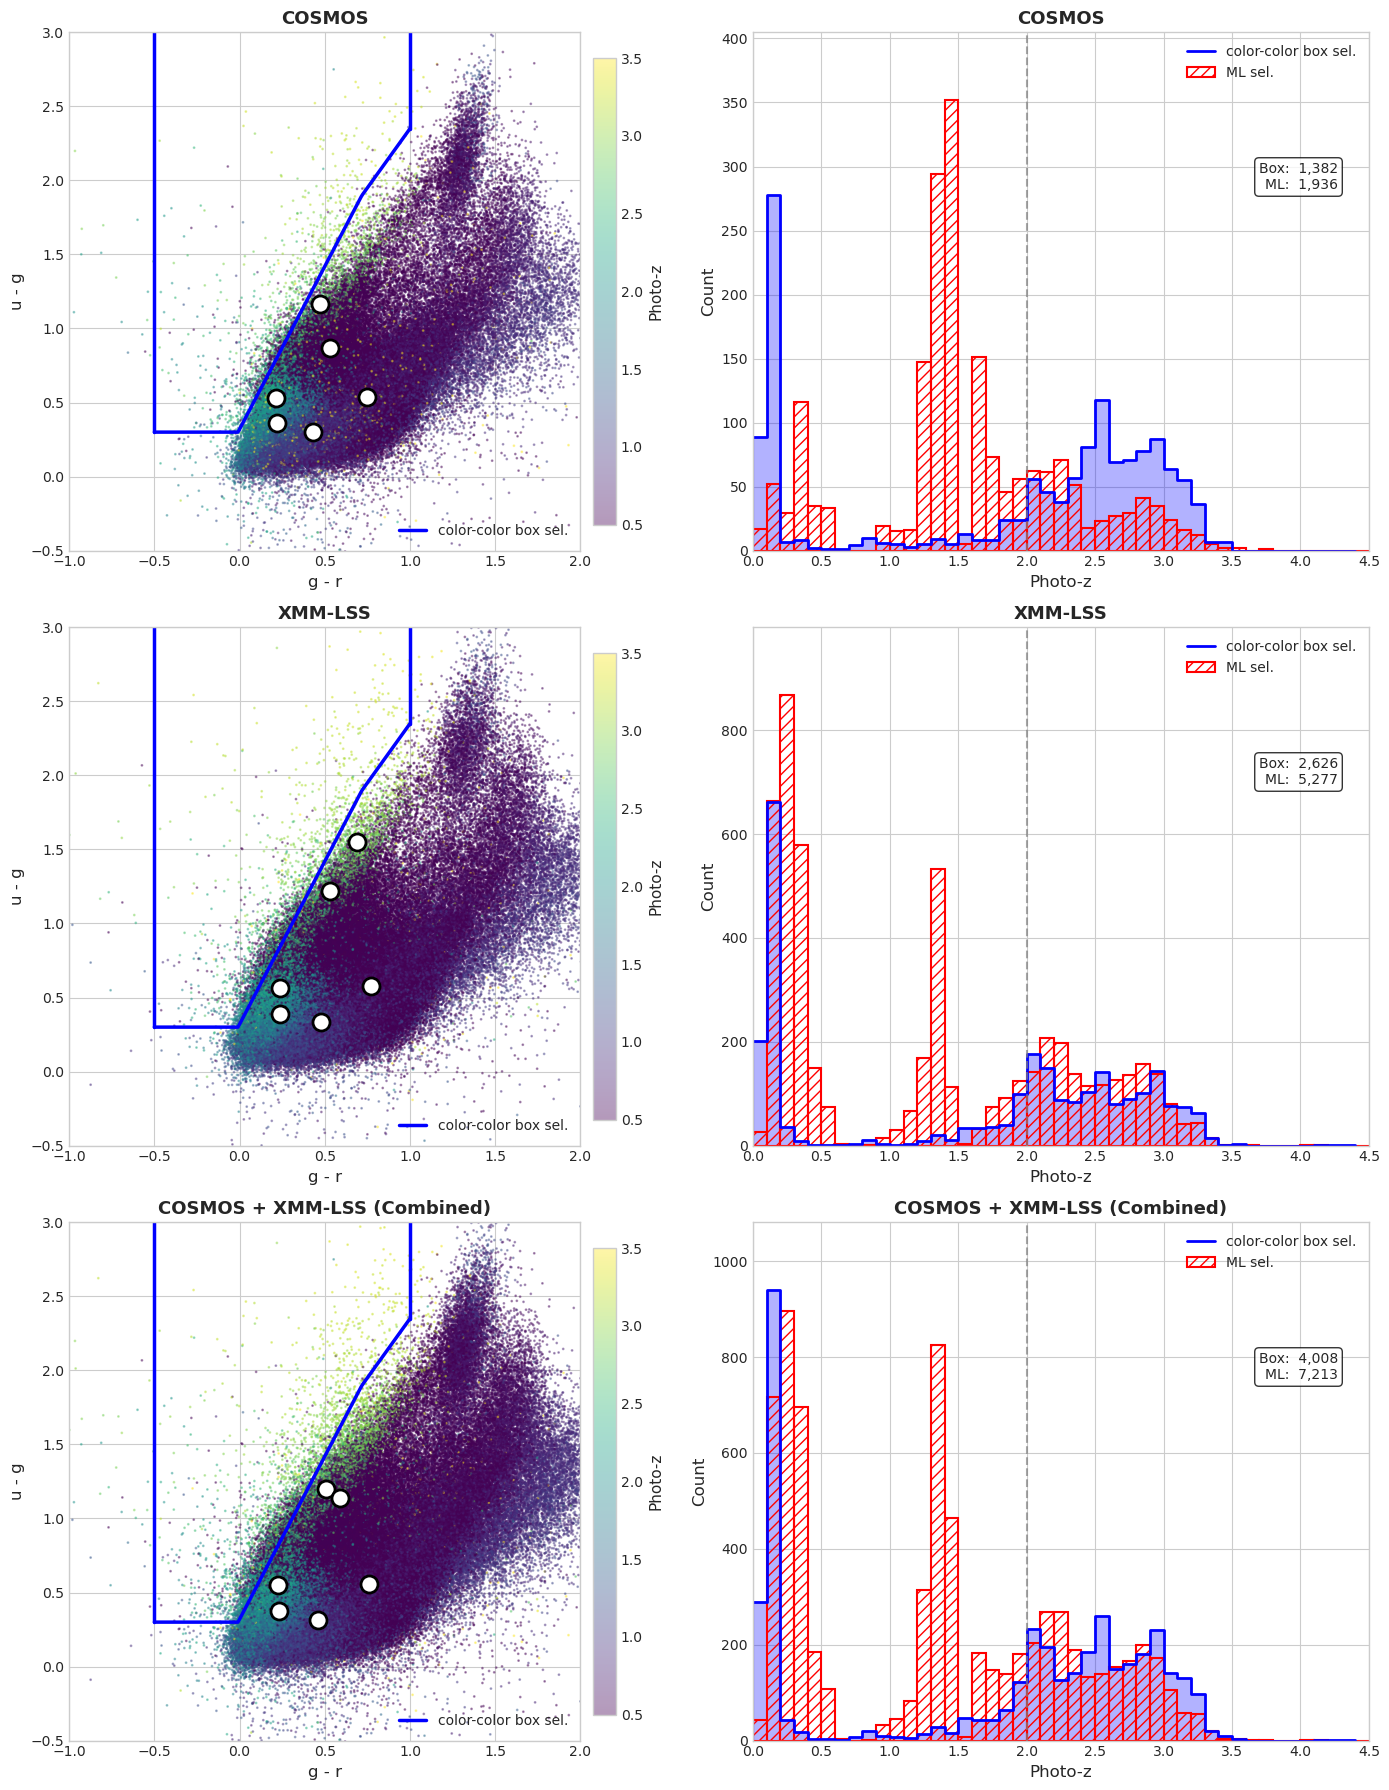

In [24]:
# Cell 15: Create Figure 5 Reproduction (Three Versions)

def plot_color_box_vs_ml(df_field, field_name, ax_color, ax_hist):
    """
    Create the two-panel figure comparing color-box and ML selection. 
    
    Parameters
    ----------
    df_field : pd.DataFrame
        DataFrame with predictions and colors
    field_name : str
        Field name for title
    ax_color : matplotlib.axes
        Axes for color-color plot
    ax_hist : matplotlib. axes
        Axes for photo-z histogram
    """
    # Convert columns to native byte order numpy arrays
    u_g_all = np.asarray(df_field['u_g'].values, dtype=np.float64)
    g_r_all = np.asarray(df_field['g_r'].values, dtype=np.float64)
    
    # Check for photo_z column
    if 'photo_z' in df_field.columns:
        photo_z_all = np.asarray(df_field['photo_z'].values, dtype=np.float64)
        valid = np.isfinite(u_g_all) & np.isfinite(g_r_all) & np.isfinite(photo_z_all)
        has_photo_z = True
    else:
        valid = np.isfinite(u_g_all) & np.isfinite(g_r_all)
        has_photo_z = False
    
    # Extract valid data
    g_r = g_r_all[valid]
    u_g = u_g_all[valid]
    
    # Get other columns for valid indices
    box_sel = np.asarray(df_field['box_sel'].values, dtype=bool)[valid]
    lbg_pred = np.asarray(df_field['lbg_pred'].values, dtype=np.int64)[valid]
    ml_sel = lbg_pred == 1
    
    if has_photo_z:
        photo_z = photo_z_all[valid]
    
    # ==========================================================================
    # Left panel: Color-Color Plot
    # ==========================================================================
    
    if has_photo_z:
        scatter = ax_color.scatter(g_r, u_g, c=photo_z, cmap='viridis',
                                    s=1, alpha=0.4, vmin=0.5, vmax=3.5, rasterized=True)
        cbar = plt.colorbar(scatter, ax=ax_color, pad=0.02, shrink=0.9)
        cbar.set_label('Photo-z', fontsize=11)
    else:
        ax_color.scatter(g_r, u_g, s=1, alpha=0.3, c='green', rasterized=True)
    
    # Draw selection box boundary
    g_r_line = np.linspace(-0.5, 1.0, 200)
    lower_bound = get_box_selection_boundary(g_r_line)
    
    # Plot the boundary polygon
    ax_color.plot(g_r_line, lower_bound, 'b-', linewidth=2.5, label='color-color box sel.')
    ax_color.plot([-0.5, -0.5], [lower_bound[0], 3.5], 'b-', linewidth=2.5)
    ax_color.plot([1.0, 1.0], [lower_bound[-1], 3.5], 'b-', linewidth=2.5)
    ax_color.plot([-0.5, 1.0], [3.5, 3.5], 'b-', linewidth=2.5)
    
    # Add mean positions for redshift bins
    if has_photo_z:
        z_bins = [(0.5, 1.0), (1.0, 1.5), (1.5, 2.0), (2.0, 2.5), (2.5, 3.0), (3.0, 3.5)]
        for z_low, z_high in z_bins:
            mask = (photo_z >= z_low) & (photo_z < z_high)
            if mask.sum() > 10:
                mean_gr = np.nanmean(g_r[mask])
                mean_ug = np.nanmean(u_g[mask])
                if np.isfinite(mean_gr) and np.isfinite(mean_ug):
                    ax_color.scatter(mean_gr, mean_ug, s=150, c='white',
                                     edgecolors='black', linewidths=2, zorder=10, marker='o')
    
    ax_color.set_xlim(-1.0, 2.0)
    ax_color.set_ylim(-0.5, 3.0)
    ax_color.set_xlabel('g - r', fontsize=12)
    ax_color.set_ylabel('u - g', fontsize=12)
    ax_color.legend(loc='lower right', fontsize=10)
    ax_color.set_title(f'{field_name}', fontsize=13, fontweight='bold')
    
    # ==========================================================================
    # Right panel: Photo-z Distribution
    # ==========================================================================
    
    if has_photo_z: 
        z_box = photo_z[box_sel]
        z_ml = photo_z[ml_sel]
        
        # Histogram bins
        bins = np.linspace(0, 4.5, 46)
        bin_width = bins[1] - bins[0]
        
        # Color-box selection (blue step + fill)
        counts_box, _ = np.histogram(z_box, bins=bins)
        ax_hist.step(bins[:-1], counts_box, where='post', color='blue',
                     linewidth=2, label='color-color box sel.')
        ax_hist.fill_between(bins[:-1], counts_box, step='post', alpha=0.3, color='blue')
        
        # ML selection (red hatched)
        counts_ml, _ = np.histogram(z_ml, bins=bins)
        ax_hist.bar(bins[:-1], counts_ml, width=bin_width, align='edge',
                    fill=False, edgecolor='red', linewidth=1.5,
                    hatch='///', label='ML sel.')
        
        # Reference line at z=2
        ax_hist.axvline(x=2.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
        
        ax_hist.set_xlim(0, 4.5)
        y_max = max(counts_box.max(), counts_ml.max()) * 1.15 if counts_box.max() > 0 or counts_ml.max() > 0 else 100
        ax_hist.set_ylim(0, y_max)
        ax_hist.set_xlabel('Photo-z', fontsize=12)
        ax_hist.set_ylabel('Count', fontsize=12)
        ax_hist.legend(loc='upper right', fontsize=10)
        ax_hist.set_title(f'{field_name}', fontsize=13, fontweight='bold')
        
        # Add statistics text
        n_box = box_sel.sum()
        n_ml = ml_sel.sum()
        stats_text = f'Box:  {n_box:,}\nML: {n_ml: ,}'
        ax_hist.text(0.95, 0.75, stats_text, transform=ax_hist.transAxes,
                     fontsize=10, verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax_hist.text(0.5, 0.5, 'Photo-z not available', transform=ax_hist.transAxes,
                     ha='center', va='center', fontsize=12)
        ax_hist.set_title(f'{field_name}', fontsize=13, fontweight='bold')


# Create the figure with 3 rows (COSMOS, XMM, BOTH)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# COSMOS
plot_color_box_vs_ml(df_cosmos, 'COSMOS', axes[0, 0], axes[0, 1])

# XMM-LSS
plot_color_box_vs_ml(df_xmm, 'XMM-LSS', axes[1, 0], axes[1, 1])

# Combined (BOTH)
plot_color_box_vs_ml(df_all, 'COSMOS + XMM-LSS (Combined)', axes[2, 0], axes[2, 1])

plt.tight_layout()
# plt.savefig(os.path.join(PREDICTION_DIR, f'color_box_vs_ml_comparison_{timestamp}.png'),
            # dpi=200, bbox_inches='tight')
plt.show()

# print(f"\n✓ Figure saved:  {PREDICTION_DIR}/color_box_vs_ml_comparison_{timestamp}.png")

In [25]:
# Cell 16: Detailed Comparison Statistics

print("=" * 70)
print("DETAILED COMPARISON:  COLOR-BOX vs ML SELECTION")
print("=" * 70)

def compute_comparison_stats(df_field, field_name):
    """Compute and print comparison statistics."""
    
    # Convert to native byte order
    u_g = np.asarray(df_field['u_g'].values, dtype=np.float64)
    g_r = np.asarray(df_field['g_r'].values, dtype=np.float64)
    
    if 'photo_z' in df_field.columns:
        photo_z = np.asarray(df_field['photo_z']. values, dtype=np.float64)
        valid = np.isfinite(u_g) & np.isfinite(g_r) & np.isfinite(photo_z)
        has_photo_z = True
    else:
        valid = np. isfinite(u_g) & np.isfinite(g_r)
        has_photo_z = False
    
    box_sel = np.asarray(df_field['box_sel']. values, dtype=bool)[valid]
    ml_sel = np.asarray(df_field['lbg_pred'].values, dtype=np.int64)[valid] == 1
    
    print(f"\n{'='*50}")
    print(f"{field_name}")
    print(f"{'='*50}")
    
    n_valid = valid.sum()
    print(f"\n[1] Selection Counts:")
    print(f"    Valid sources: {n_valid:,}")
    print(f"    Color-box:  {box_sel.sum():,} ({box_sel.sum()/n_valid*100:.2f}%)")
    print(f"    ML: {ml_sel.sum():,} ({ml_sel.sum()/n_valid*100:.2f}%)")
    
    # Overlap analysis
    both = box_sel & ml_sel
    box_only = box_sel & ~ml_sel
    ml_only = ~box_sel & ml_sel
    
    print(f"\n[2] Overlap Analysis:")
    print(f"    Both methods: {both.sum():,}")
    print(f"    Box only: {box_only.sum():,}")
    print(f"    ML only: {ml_only.sum():,}")
    
    result = {
        'field': field_name,
        'n_valid': n_valid,
        'n_box': box_sel.sum(),
        'n_ml': ml_sel.sum(),
        'n_both': both.sum(),
    }
    
    if has_photo_z:
        photo_z_valid = photo_z[valid]
        
        print(f"\n[3] Redshift Statistics:")
        
        # Color-box
        z_box = photo_z_valid[box_sel]
        if len(z_box) > 0:
            print(f"    Color-box selection:")
            print(f"      Mean z: {z_box.mean():.3f}")
            print(f"      Median z: {np.median(z_box):.3f}")
            print(f"      z > 2: {(z_box > 2).sum():,} ({(z_box > 2).sum()/len(z_box)*100:.1f}%)")
            print(f"      z > 2. 5: {(z_box > 2.5).sum():,} ({(z_box > 2.5).sum()/len(z_box)*100:.1f}%)")
        
        # ML
        z_ml = photo_z_valid[ml_sel]
        if len(z_ml) > 0:
            print(f"    ML selection:")
            print(f"      Mean z: {z_ml.mean():.3f}")
            print(f"      Median z: {np.median(z_ml):.3f}")
            print(f"      z > 2: {(z_ml > 2).sum():,} ({(z_ml > 2).sum()/len(z_ml)*100:.1f}%)")
            print(f"      z > 2.5: {(z_ml > 2.5).sum():,} ({(z_ml > 2.5).sum()/len(z_ml)*100:.1f}%)")
        
        # Performance metrics (using z > 2 as "true" LBG)
        true_lbg = photo_z_valid > 2
        
        print(f"\n[4] Performance (z > 2 as ground truth):")
        print(f"    True LBG in sample: {true_lbg.sum():,}")
        
        # Color-box
        box_tp = (box_sel & true_lbg).sum()
        box_fp = (box_sel & ~true_lbg).sum()
        box_fn = (~box_sel & true_lbg).sum()
        box_prec = box_tp / (box_tp + box_fp) if (box_tp + box_fp) > 0 else 0
        box_rec = box_tp / (box_tp + box_fn) if (box_tp + box_fn) > 0 else 0
        box_f1 = 2 * box_prec * box_rec / (box_prec + box_rec) if (box_prec + box_rec) > 0 else 0
        
        print(f"    Color-box:  Precision={box_prec:.3f}, Recall={box_rec:.3f}, F1={box_f1:.3f}")
        
        # ML
        ml_tp = (ml_sel & true_lbg).sum()
        ml_fp = (ml_sel & ~true_lbg).sum()
        ml_fn = (~ml_sel & true_lbg).sum()
        ml_prec = ml_tp / (ml_tp + ml_fp) if (ml_tp + ml_fp) > 0 else 0
        ml_rec = ml_tp / (ml_tp + ml_fn) if (ml_tp + ml_fn) > 0 else 0
        ml_f1 = 2 * ml_prec * ml_rec / (ml_prec + ml_rec) if (ml_prec + ml_rec) > 0 else 0
        
        print(f"    ML: Precision={ml_prec:.3f}, Recall={ml_rec:.3f}, F1={ml_f1:.3f}")
        
        result. update({
            'box_precision': box_prec,
            'box_recall': box_rec,
            'box_f1': box_f1,
            'ml_precision': ml_prec,
            'ml_recall': ml_rec,
            'ml_f1': ml_f1,
        })
    
    return result


# Compute stats for all fields
stats_list = []
for name, df_field in [('COSMOS', df_cosmos), ('XMM-LSS', df_xmm), ('Combined', df_all)]:
    stats = compute_comparison_stats(df_field, name)
    stats_list.append(stats)

# Create summary table
stats_df = pd.DataFrame(stats_list)

print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(stats_df.to_string(index=False))

# Save summary
stats_df.to_csv(os.path.join(PREDICTION_DIR, f'selection_comparison_{timestamp}.csv'), index=False)
print(f"\n✓ Summary saved: {PREDICTION_DIR}/selection_comparison_{timestamp}.csv")

DETAILED COMPARISON:  COLOR-BOX vs ML SELECTION

COSMOS

[1] Selection Counts:
    Valid sources: 153,220
    Color-box:  1,382 (0.90%)
    ML: 1,936 (1.26%)

[2] Overlap Analysis:
    Both methods: 160
    Box only: 1,222
    ML only: 1,776

[3] Redshift Statistics:
    Color-box selection:
      Mean z: 1.864
      Median z: 2.372
      z > 2: 872 (63.1%)
      z > 2. 5: 593 (42.9%)
    ML selection:
      Mean z: 1.558
      Median z: 1.443
      z > 2: 480 (24.8%)
      z > 2.5: 217 (11.2%)

[4] Performance (z > 2 as ground truth):
    True LBG in sample: 8,776
    Color-box:  Precision=0.631, Recall=0.099, F1=0.172
    ML: Precision=0.248, Recall=0.055, F1=0.090

XMM-LSS

[1] Selection Counts:
    Valid sources: 196,215
    Color-box:  2,626 (1.34%)
    ML: 5,277 (2.69%)

[2] Overlap Analysis:
    Both methods: 354
    Box only: 2,272
    ML only: 4,923

[3] Redshift Statistics:
    Color-box selection:
      Mean z: 1.653
      Median z: 2.065
      z > 2: 1,412 (53.8%)
      z >